In [18]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools
from ppi import plot_contact_profile
from orf import orf_get_alternates

%load_ext autoreload 
%autoreload 2

seq_to_gene_id_map = pd.read_csv('../data/genes/genes.csv', usecols=['gene_id', 'seq']).set_index('seq').gene_id.to_dict()
gene_id_to_cluster_id_map = json.load(open('../data/genes/clusters.json'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
msa_dir_path = '../data/genes/mmseqs/msa'

def get_msas_unpaired(gene_ids:list, dir_path:str=msa_dir_path):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}


# Cluster analysis: **cluster_4**

In [20]:
cluster_id = 4 

In [21]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[(genes_df.cluster_id == cluster_id)].copy()

# Write the protein sequences to a FASTA file and create an MSA. 
msa_path = f'../data/genes/cluster_{cluster_id}.afa'
FASTAFile.from_df(genes_df).write(f'../data/genes/cluster_{cluster_id}.faa')
if not os.path.exists(msa_path):
    subprocess.run(f'muscle -align ../data/genes/cluster_{cluster_id}.faa -output {msa_path}', shell=True, check=True)
msa = MSAFile.from_file(msa_path)

print('Number of genes:', len(genes_df))
print('Maximum length:', genes_df.seq.apply(len).max())
print('Minimum length:', genes_df.seq.apply(len).min())

print()
print(str(FASTAFile.from_df(genes_df)))

Number of genes: 10
Maximum length: 125
Minimum length: 90

>orfm.bz_5.1_103
MNKTFIFILLLILIPLSSANINLTVQSSNEKNITIVSLNNNNIVGYITNNETINLPNDNYIIKVRTISTKFNVTNFLNIQDKINKDYLYIFVFVFAFIVIIVGLKLVKKL
>orfm.bz_7.1_105
MTINISVLSEINRTIEIIPISSMSVQNTLFSNQYTNNITYSNYIIKLGTIHTNFSNNSFITVKNSMIGDFTNLFILFTMLICIYFFIGYLKKL
>orfm.bz_1.1_79
MTINLIISSENNKNIILTRLDNFTSINFTQNSIQNNIDYTNYLINIKTSTSLGLNDMWNMIDNITKDYAIIAVLFVALLMLIFGVQYIRKLGEE
>orfm.bz_9.1_105
MINITIQSENLRTIDLIRLSDFNVTQSFLNNETVNTSYDNYIIKILNSDSSFSIYNFWNQADSLIGSIIFIVIIGIVLISVVSFINYLRRM
>orfm.bz_3.1_94
MINLTIQSENNKIINIIDIGNNSLINTTSNNNTLYLDYNNLLIDIHTNTSLNFTKFYENSSNITNDGLWIFFVIILFGCLFFATKLIKKL
>orfm.bz_8.1_149
MINITIQSLNNKTIDVTNLDTFSKIYTNISNNQTINSSYSNLIIDIKTSTTSLSIPNFFNNLKSINSDVSFFFVFVISVFLVWMLIKLVKRLE
>orfm.bz_2.1_92
MINLTIQSLNNKTVSITNFDNFNKVYSNISNNLSIPLDYNNYLVEIGTKTSSLSLDNFWNNLSSITKDGIFLIISIIIIFTVIMVTKYFKKL
>orfm.bz_11.1_113
LVIMNKIKKLVWVLFIVIIFSFLIIPVSANVNITFLSDNEQVIKVINIDTGYNEISTNSTNQTINLSYNNFVFKLYPTNTKIVNNNGTFIINNFKDFNNDAYLVIWIGVIFGLIILFFKFFGSRL
>orfm.bz_4

In [22]:
annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
tmhmm_df = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt').to_df()
deep_tmhmm_df = pd.concat([DeepTMHMMFile.from_file(path).to_df() for path in glob.glob(f'../data/genes/deep_tmhmm/*gff3')])
signalp_df = pd.concat([pd.read_csv(path, sep='\t', comment='#', names=SIGNALP_FIELDS) for path in glob.glob(f'../data/genes/signalp/*txt')]).set_index('gene_id')

table_df = pd.DataFrame(index=genes_df.index.values)
table_df['Number of annotations'] = annot_df.groupby('gene_id').size() # .fillna(0).astype(int)
table_df['Number of TMHs (TMHMM)'] = tmhmm_df[(tmhmm_df.annotation == 'TMhelix')].groupby('gene_id').size()# .fillna(0) #.astype(int)
table_df['Topology string'] = deep_tmhmm_df[~deep_tmhmm_df.index.duplicated()].topology_string
table_df['SignalP prediction'] = signalp_df.prediction
table_df = table_df.fillna(0)
print(table_df.to_string())

                  Number of annotations  Number of TMHs (TMHMM) Topology string SignalP prediction
orfm.bz_5.1_103                     0.0                       2            SOMI                 SP
orfm.bz_7.1_105                     0.0                       1             OMI              OTHER
orfm.bz_1.1_79                      0.0                       1             OMI              OTHER
orfm.bz_9.1_105                     0.0                       1             OMI              OTHER
orfm.bz_3.1_94                      0.0                       1             OMI              OTHER
orfm.bz_8.1_149                     0.0                       1             OMI              OTHER
orfm.bz_2.1_92                      0.0                       1             OMI              OTHER
orfm.bz_11.1_113                    0.0                       2            SOMI                 SP
orfm.bz_4.1_126                     0.0                       2            SOMI                 SP
orfm.bz_0.

In [23]:
for row in genes_df.itertuples():
    if signalp_df.loc[row.Index, 'prediction'] == 'SP':
        cleavage_site = re.search(r'CS pos: (\d+)', signalp_df.loc[row.Index, 'cleavage_site_position']).group(1)
        genes_df.loc[row.Index, 'seq_processed'] = row.seq[int(cleavage_site):]
        genes_df.loc[row.Index, 'cleavage_site'] = int(cleavage_site)
    else:
        genes_df.loc[row.Index, 'seq_processed'] = row.seq

print()
print(str(FASTAFile.from_df(genes_df.assign(seq=genes_df.seq_processed))))


>orfm.bz_5.1_103
NINLTVQSSNEKNITIVSLNNNNIVGYITNNETINLPNDNYIIKVRTISTKFNVTNFLNIQDKINKDYLYIFVFVFAFIVIIVGLKLVKKL
>orfm.bz_7.1_105
MTINISVLSEINRTIEIIPISSMSVQNTLFSNQYTNNITYSNYIIKLGTIHTNFSNNSFITVKNSMIGDFTNLFILFTMLICIYFFIGYLKKL
>orfm.bz_1.1_79
MTINLIISSENNKNIILTRLDNFTSINFTQNSIQNNIDYTNYLINIKTSTSLGLNDMWNMIDNITKDYAIIAVLFVALLMLIFGVQYIRKLGEE
>orfm.bz_9.1_105
MINITIQSENLRTIDLIRLSDFNVTQSFLNNETVNTSYDNYIIKILNSDSSFSIYNFWNQADSLIGSIIFIVIIGIVLISVVSFINYLRRM
>orfm.bz_3.1_94
MINLTIQSENNKIINIIDIGNNSLINTTSNNNTLYLDYNNLLIDIHTNTSLNFTKFYENSSNITNDGLWIFFVIILFGCLFFATKLIKKL
>orfm.bz_8.1_149
MINITIQSLNNKTIDVTNLDTFSKIYTNISNNQTINSSYSNLIIDIKTSTTSLSIPNFFNNLKSINSDVSFFFVFVISVFLVWMLIKLVKRLE
>orfm.bz_2.1_92
MINLTIQSLNNKTVSITNFDNFNKVYSNISNNLSIPLDYNNYLVEIGTKTSSLSLDNFWNNLSSITKDGIFLIISIIIIFTVIMVTKYFKKL
>orfm.bz_11.1_113
NVNITFLSDNEQVIKVINIDTGYNEISTNSTNQTINLSYNNFVFKLYPTNTKIVNNNGTFIINNFKDFNNDAYLVIWIGVIFGLIILFFKFFGSRL
>orfm.bz_4.1_126
SINITFISDNEKVINVFDLDNKTNQISSNVTNEITELEYKNYNIKLYPSNTQITKDNGSFIFNNLNDFNNDYMLLMYLAIIIFILYLFFKIFGSRL
>or

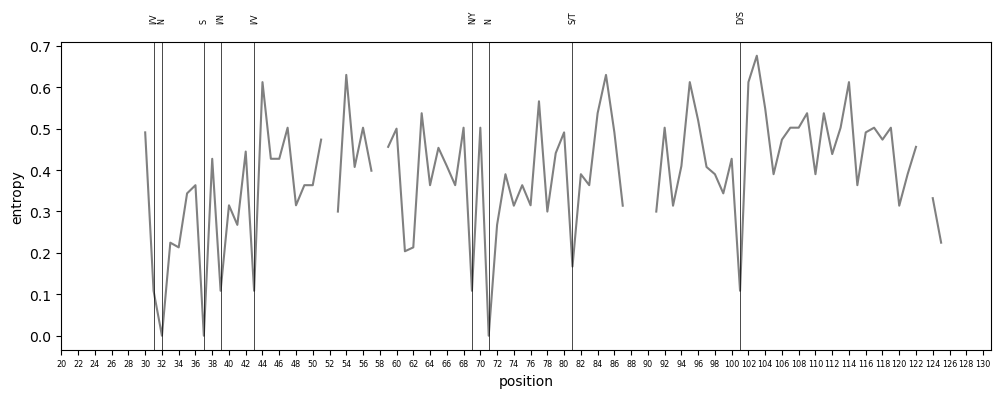

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_entropy(msa, ax=ax, annotate=True, x_max=msa.n_cols)
plt.show()

## Protein-protein interactions

In [25]:
def get_contact_id(row, ref_cluster_id:int=cluster_id):
    '''Construct a contact ID from a contact_df entry. These IDs are of the form {node_type}:{position}. The contact IDs are necessarily order-invariant; 
    in other words, the contact ID for an edge (u, v) must be the same ad the contact ID for (v, u).
    
    For these contact IDs, the reference cluster ID is always the first node. The node types are the original OrfM 
    gene IDs (rather than the cluster ID), so the contact IDs can be mapped more easily to gene metadata.
    '''
    ref_idx = 0 if (row.cluster_id_0 == ref_cluster_id) else 1
    idx = int((not ref_idx))

    ref_gene_id, ref_residue_num = getattr(row, f'gene_id_{ref_idx}'), getattr(row, f'residue_num_{ref_idx}')
    gene_id, residue_num = getattr(row, f'gene_id_{idx}'), getattr(row, f'residue_num_{idx}')
    contact_id = f'{ref_gene_id}:{ref_residue_num}-{gene_id}:{residue_num}'
    return contact_id


def get_proximity(contact_id, genes_df=pd.read_csv('../data/genes/genes.csv', index_col=0)):
    '''Takes a contact ID (constructed using the get_contact_id function above) and calculate
    the distance between the two corresponding genes on the genome. If the genes overlap, return 0.'''
    
    ref_gene_id, gene_id = contact_id.split('-')
    ref_gene_id, gene_id = ref_gene_id.split(':')[0], gene_id.split(':')[0]
    
    ref_start, ref_stop = genes_df.loc[ref_gene_id].start, genes_df.loc[ref_gene_id].stop
    start, stop = genes_df.loc[gene_id].start, genes_df.loc[gene_id].stop

    if not (((ref_start - stop)  >  0) or ((start - ref_stop)  >  0)): # Handle overlaps. 
        return 0 
    else:
        return max((ref_start - stop), (start - ref_stop))


# contacts_df['proximity'] = contacts_df.contact_id.apply(get_orf_proximity)


In [26]:
contacts_df = list()
for genome_id in ['bz_0', 'bz_1', 'bz_2', 'bz_3', 'bz_4']:
    contacts_path = f'0-ppi-{genome_id}_pairwise_contacts.csv'
    contacts_df += [pd.read_csv(contacts_path)]

contacts_df = pd.concat(contacts_df)
contacts_df['gene_id_0'] = contacts_df.seq_0.map(seq_to_gene_id_map)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(seq_to_gene_id_map)
contacts_df['cluster_id_0'] = contacts_df.gene_id_0.map(gene_id_to_cluster_id_map)
contacts_df['cluster_id_1'] = contacts_df.gene_id_1.map(gene_id_to_cluster_id_map)
contacts_df = contacts_df[(contacts_df.cluster_id_0 == cluster_id) | (contacts_df.cluster_id_1 == cluster_id)].copy()

contacts_df['ref_cluster_id'] = cluster_id
contacts_df['cluster_id'] = np.where(contacts_df.cluster_id_0 == contacts_df.ref_cluster_id, contacts_df.cluster_id_1, contacts_df.cluster_id_0)
contacts_df['ref_residue_num'] = np.where(contacts_df.cluster_id_0 == contacts_df.ref_cluster_id, contacts_df.residue_num_0, contacts_df.residue_num_1)
contacts_df['residue_num'] = np.where(contacts_df.cluster_id_0 == contacts_df.ref_cluster_id, contacts_df.residue_num_1, contacts_df.residue_num_0)

contacts_df['genome_id'] = contacts_df.gene_id_0.apply(get_genome_id)
contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)
contacts_df['interface_size'] = contacts_df.groupby(['name', 'model']).transform('size') 

# Configure the DataFrame so that there is one entry per model (there will be three models for every gene pair, as num_seeds=3). 
# Then create maps for the following quantities:
#   (1) the number of models per gene pair which supports the contact.
#   (2) the number of models per cluster ID which support the contact (across all genomes).

num_models_per_gene_pair = contacts_df.drop_duplicates(['name', 'model']).groupby('name').size()
num_models_per_cluster = contacts_df.drop_duplicates(['name', 'model']).groupby('cluster_id').size()
contacts_df['num_models_per_gene_pair'] = contacts_df.name.map(num_models_per_gene_pair)
contacts_df['num_models_per_cluster'] = contacts_df.cluster_id.map(num_models_per_cluster)

filters = dict()
filters['small_interface'] = contacts_df.interface_size < 5 # Require at least 5 residues predicted to be in contact. 
filters['insufficient_support'] = contacts_df.num_models_per_gene_pair < 3 # Require that at least 2/3 seeds support the contact. 

contacts_df = apply_filters(filters, contacts_df)

print(f'Number of potential interacting pairs:', contacts_df.cluster_id.nunique())


apply_filters: 38 entries removed by small_interface.
apply_filters: 199 entries removed by insufficient_support.
Number of potential interacting pairs: 22


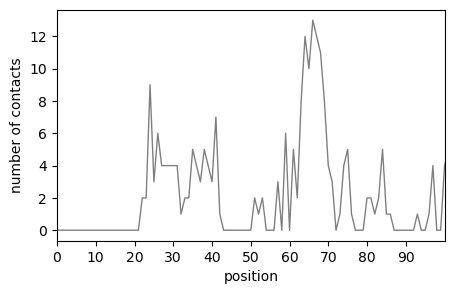

In [27]:
fig, ax = plt.subplots(figsize=(5, 3))

for gene_id in ['orfm.bz_0.1_118']:
    plot_contact_profile(contacts_df, ax=ax, node_type=gene_id)
    
ax.set_ylabel('number of contacts')
plt.show()

# The transmembrane helix extends from around residue 70 to residue 90 of the processed protein (so residues 90-110 of 
# the full-length protein). It is clear that the bulk of the contacts occur in the outer membrane region. 

In [36]:
contigs = {gene_id:FASTAFile.from_file(os.path.join('../data/genomes', f'{get_genome_id(gene_id)}.fasta')).seqs[0] for gene_id in genes_df.index}

df = pd.concat([orf_get_alternates(int(row.start), int(row.stop), strand=row.strand, contig=contigs[row.Index]).assign(gene_id=row.Index) for row in genes_df.itertuples()])

filters = dict()
filters['in_frame_stop_codon'] = df.seq.str.count(r'\*') > 1
filters['rare_start_codon'] = df.start_codon == 'TTG'
filters['too_short'] = df.seq.apply(len) < 75

df = apply_filters(filters, df)
df

apply_filters: 11 entries removed by in_frame_stop_codon.
apply_filters: 13 entries removed by rare_start_codon.
apply_filters: 8 entries removed by too_short.


,start_codon,nt_seq,seq,frame_shift,original_length,length,gene_id
0,ATG,ATGAACAAAACCTTTATTTTTATTTTACTTTTAATACTAATTCCTT...,MNKTFIFILLLILIPLSSANINLTVQSSNEKNITIVSLNNNNIVGY...,0,111,111,orfm.bz_5.1_103
2,ATG,ATGACAATAAATATATCCGTTTTAAGCGAAATAAATAGAACAATAG...,MTINISVLSEINRTIEIIPISSMSVQNTLFSNQYTNNITYSNYIIK...,0,94,94,orfm.bz_7.1_105
1,ATG,ATGACAATTAACTTAATAATTTCTTCTGAAAATAATAAAAATATTA...,MTINLIISSENNKNIILTRLDNFTSINFTQNSIQNNIDYTNYLINI...,0,95,95,orfm.bz_1.1_79
3,ATG,ATGATAAACATTACTATTCAATCGGAAAACTTGAGAACCATTGACT...,MINITIQSENLRTIDLIRLSDFNVTQSFLNNETVNTSYDNYIIKIL...,0,92,92,orfm.bz_9.1_105
0,ATG,ATGATAAATTTAACAATTCAATCTGAAAATAATAAAATAATAAATA...,MINLTIQSENNKIINIIDIGNNSLINTTSNNNTLYLDYNNLLIDIH...,0,91,91,orfm.bz_3.1_94
1,ATG,ATGATAAACATAACAATCCAAAGTTTAAATAATAAAACTATTGATG...,MINITIQSLNNKTIDVTNLDTFSKIYTNISNNQTINSSYSNLIIDI...,0,94,94,orfm.bz_8.1_149
0,ATG,ATGATAAACTTAACAATACAATCATTAAATAATAAAACTGTAAGCA...,MINLTIQSLNNKTVSITNFDNFNKVYSNISNNLSIPLDYNNYLVEI...,0,93,93,orfm.bz_2.1_92
1,ATG,ATGAACAAAATAAAAAAATTAGTATGGGTTTTGTTCATAGTTATTA...,MNKIKKLVWVLFIVIIFSFLIIPVSANVNITFLSDNEQVIKVINID...,0,126,123,orfm.bz_11.1_113
1,ATG,ATGAATAAAATAAATAATACTCAAAAAATTATTTTATTCATGATAT...,MNKINNTQKIILFMIFSFLIIPVNASINITFISDNEKVINVFDLDN...,0,122,122,orfm.bz_4.1_126
2,ATG,ATGATATTTTCTTTTTTAATTATCCCTGTAAATGCTTCTATAAATA...,MIFSFLIIPVNASINITFISDNEKVINVFDLDNKTNQISSNVTNEI...,0,122,109,orfm.bz_4.1_126


## Oligomerization 

The pairwise protein-protein interaction data suggests that cluster_4 proteins may interact with themselves. Because cluster_4 is present in the Betazoid  region which is plausibly related to phage virion structure, it is possible that these membrane-associated proteins are capsid components (e.g. minor coat proteins). If 



In [ ]:
def cleave_msa(msa:str, cleavage_site:int, seq_processed:str=None):
    '''Modify the MSA so that it can be used with a processed sequence, i.e. a sequence with the signal peptide removed.'''
    if np.isnan(cleavage_site):
        return msa 

    file = FASTAFile.from_text(msa)
    file.seqs = [seq[int(cleavage_site):] for seq in file.seqs]
    assert file.seqs[0] == seq_processed, f'cleave_msa: Expected the first MSA sequence to be equal to {seq_processed}.'
    return str(file)

In [ ]:
use_custom_msas = True
msas = get_msas_unpaired(genes_df.index)    

In [77]:
alphafold_dir = '../data/genes/alphafold/'
alphafold_input_dir = os.path.join(alphafold_dir, 'af_input', f'cluster_{cluster_id}' if (not use_custom_msas) else f'cluster_{cluster_id}-custom_msa')
alphafold_output_dir = os.path.join(alphafold_dir, 'af_output', f'cluster_{cluster_id}' if (not use_custom_msas) else f'cluster_{cluster_id}-custom_msa')
os.makedirs(alphafold_input_dir, exist_ok=True)

alphafold_params = dict()
alphafold_params['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. Reduced to mitigate runtime.
alphafold_params['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime. 

In [78]:
for num_subunits in np.arange(1, 9): # The most likely oligomerization states. 
    for row in genes_df.itertuples():

        name = f'{row.Index}_{num_subunits}mer'
        input = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=3, version=2) # Use 3 seeds rather than the default 5 to reduce runtime.

        unpaired_msa = msas.get(row.Index, None)
        unpaired_msa = cleave_msa(unpaired_msa, row.cleavage_site, seq_processed=row.seq_processed)
        paired_msa = '' if (unpaired_msa is not None) else None
        

        input.add_seq(row.seq_processed, n=num_subunits, paired_msa=paired_msa, unpaired_msa=unpaired_msa)

        input.write(os.path.join(alphafold_input_dir, f'{name}.json'))

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(alphafold_input_dir)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in alphafold_params.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_4-custom_msa/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 5"


## Foldseek search 


In [37]:
# foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_SEARCH_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*')])
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_SEARCH_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes_prodigal-custom_msa*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)].copy()

filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 50
filters['target_too_long'] = foldseek_search_df.target_length > 200

foldseek_search_df = apply_filters(filters, foldseek_search_df)

apply_filters: 7048 entries removed by low_tm_score.
apply_filters: 782 entries removed by short_alignment.
apply_filters: 10574 entries removed by target_too_long.


In [49]:
foldseek_search_df[foldseek_search_df.category == 'none'].target_header.drop_duplicates().iloc[-50:].tolist()
# foldseek_search_df[foldseek_search_df.category == 'nucleoid-associated protein'].target_header.drop_duplicates().tolist()
# foldseek_search_df[foldseek_search_df.category == 'DNA-binding protein'].target_header.drop_duplicates().tolist()
# foldseek_search_df

['AF-P40338-F1-model_v6 von Hippel-Lindau disease tumor suppressor',
 'AF-Q6AY64-F1-model_v6 UPF0669 protein C6orf120 homolog',
 'AF-Q9DAY5-F1-model_v6 UPF0669 protein C6orf120 homolog',
 'AF-P35496-F1-model_v6 Major seminal plasma glycoprotein PSP-II',
 'AF-Q4ZJN1-2-F1-model_v6 Complement C1q and tumor necrosis factor-related protein 9',
 'AF-P83004-F1-model_v6 13S globulin basic chain',
 'AF-Q5ZLK8-F1-model_v6 UPF0669 protein C6orf120 homolog',
 'AF-Q0D1U6-F1-model_v6 3-hydroxyanthranilate 3,4-dioxygenase',
 'AF-Q4WCF1-F1-model_v6 3-hydroxyanthranilate 3,4-dioxygenase 1',
 'AF-P55001-F1-model_v6 Microfibrillar-associated protein 2',
 'AF-Q6NMJ2-F1-model_v6 Pollen-specific protein-like At4g18596',
 'AF-Q9X6J6-F1-model_v6 Transcription attenuation protein MtrB',
 'AF-Q25214-F1-model_v6 Protein scalloped (Fragment)',
 'AF-A0A0B4J275-F1-model_v6 T cell receptor alpha variable 17',
 'AF-P0CP96-F1-model_v6 FK506-binding protein 2',
 'AF-Q9JHG0-F1-model_v6 Cerebellin-3',
 'AF-C1ERL1-F1-mode

In [51]:
categories = dict()
categories['emp24 domain-containing protein'] = foldseek_search_df.target_header.str.contains('emp24', case=False)
categories['large ribosomal subunit protein'] = foldseek_search_df.target_header.str.contains('large ribosomal subunit protein', case=False)
categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized', case=False)
categories['nucleoid-associated protein'] = foldseek_search_df.target_header.str.contains('nucleoid', case=False)
categories['peptidyl-prolyl cis-trans isomerase'] = foldseek_search_df.target_header.str.contains('peptidyl-prolyl', case=False)
categories['carboxypeptidase regulatory-like protein'] = foldseek_search_df.target_header.str.contains('carboxypeptidase', case=False)
categories['ribosome biogenesis protein'] = foldseek_search_df.target_header.str.contains('ribosome biogenesis protein', case=False)
categories['DNA-binding protein'] = foldseek_search_df.target_header.str.contains('DNA-binding', case=False)
categories['transcriptional regulator'] = foldseek_search_df.target_header.str.contains('transcriptional repressor|transcriptional|transcription factor|helix-turn-helix', case=False)
categories['carbohydrate-binding protein'] = foldseek_search_df.target_header.str.contains('carbohydrate', case=False)
categories['prefoldin'] = foldseek_search_df.target_header.str.contains('prefoldin', case=False)
categories['phage virion morphogenesis'] = foldseek_search_df.target_header.str.contains('Phage virion morphogenesis', case=False)
categories['DUF192 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF192|UPF0127', case=False)
categories['DUF3592 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF3592', case=False)
categories['DUF1178 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF1178', case=False)
categories['tubulin'] = foldseek_search_df.target_header.str.contains('tubulin|Stathmin', case=False)
categories['nuclease'] = foldseek_search_df.target_header.str.contains('nuclease|GIY-YIG', case=False)
categories['FlgC'] = foldseek_search_df.target_header.str.contains('FlgC', case=False)
categories['tail fiber protein'] = foldseek_search_df.target_header.str.contains('tail fiber', case=False)
categories['glucose-6-phosphate isomerase'] = foldseek_search_df.target_header.str.contains('Glucose-6-phosphate isomerase', case=False)
categories['S-protein'] = foldseek_search_df.target_header.str.contains('S-protein|S protein|pollen allergen', case=False) # These are secreted plant proteins, probably false positives. https://www.ebi.ac.uk/interpro/entry/InterPro/IPR010264/
categories['ApaG'] = foldseek_search_df.target_header.str.contains('ApaG', case=False) # Function is unknown, not a protein–protein interaction role. Not typically membrane-associated. May form a homo-tetramer, see https://www.rcsb.org/structure/3SB3
categories['microfibrillar-associated'] = foldseek_search_df.target_header.str.contains('Microfibrillar', case=False) # Also secreted extracellular proteins with signal peptides
# categories[''] = foldseek_search_df.target_header.str.contains('', case=False)
# categories[''] = foldseek_search_df.target_header.str.contains('', case=False)

foldseek_search_df['category'] = np.select(*list(zip(*categories.items()))[::-1], default='none')


Based on the Foldseek search results, it seems that the cluster_8 gene encodes a helix-turn-helix transcriptional regulator. This suggests that it binds a specific DNA motif. Given its conserved position at the start of what appears to be the Betazoid replication cluster, it is likely this site is somewhere in the region upstream of this cluster.

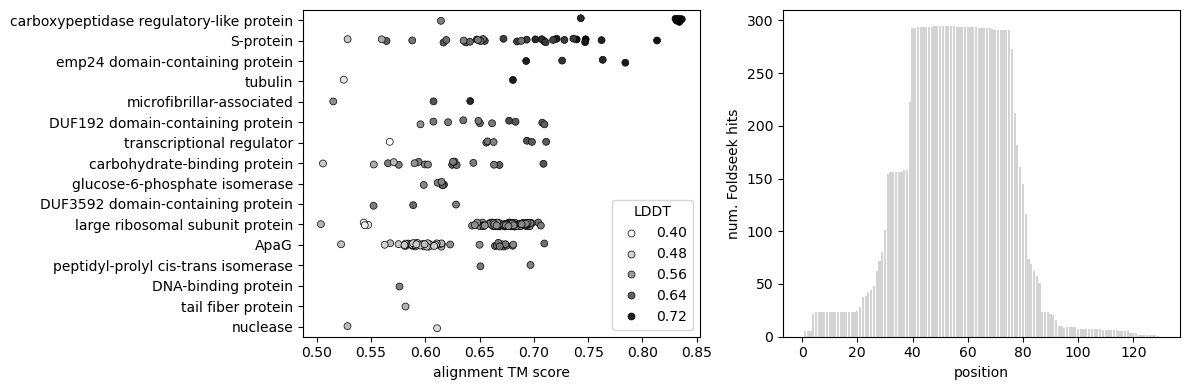

In [52]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

ax = axes[0]

figure_df = foldseek_search_df[~foldseek_search_df.category.isin(['none', 'uncharacterized'])].copy()
figure_df = figure_df.sort_values('lddt', ascending=False).drop_duplicates('target_id') # Keep the best hit to each target. 
sns.stripplot(figure_df, y='category', x='alignment_tm_score', ax=ax, hue='lddt', palette='Grays', edgecolor='black', linewidth=0.5)
ax.set_xlabel('alignment TM score')
ax.get_legend().set_title('LDDT')
ax.set_ylabel('')

ax = axes[1]
# Get the Foldseek hit start and stop indices relative to the MSAFile. 
figure_df['msa_start'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_start, row.query_id), axis=1) 
figure_df['msa_stop'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_end, row.query_id), axis=1) 

positions = np.arange(msa.n_cols)
heights = np.zeros(len(positions))
for row in figure_df.itertuples():
    heights[np.arange(row.msa_start, row.msa_stop)] += 1 

ax.bar(positions, heights, color='lightgray', lw=0, edgecolor='black')
ax.set_ylabel('num. Foldseek hits')
ax.set_xlabel('position')

fig.tight_layout()
plt.show()